## Training

In [ ]:

import os
import sys
import shutil
import subprocess
import torch
import glob
import scipy.io as io
import numpy as np
import urllib.request

# --- 1. CONFIGURATION ---
PROJECT_DIR = r"C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project"
DATASET_ROOT = os.path.join(PROJECT_DIR, 'railway_dataset2')
REPO_DIR = os.path.join(PROJECT_DIR, 'CrowdCounting-P2PNet')
PRETRAINED_WEIGHTS = os.path.join(PROJECT_DIR, 'SHTechA.pth')
CLEAN_CKPT = os.path.join(REPO_DIR, 'latest.pth')

# GPU Config
NUM_GPUS = 2
BATCH_SIZE = 4
EPOCHS = 100
LR = 1e-6
WORKERS = 0     

# Reset Directory
if os.getcwd() != PROJECT_DIR: os.chdir(PROJECT_DIR)

print(f"=== REPAIR & TRAIN PIPELINE ===")

# 2. REPO SETUP
if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    subprocess.check_call(["git", "clone", "https://github.com/TencentYoutuResearch/CrowdCounting-P2PNet.git", REPO_DIR])

os.chdir(REPO_DIR)

# 3. FIX CORRUPTED VGG WEIGHTS (The Critical Fix)
# ------------------------------------------------------------------------------
vgg_path = os.path.join(REPO_DIR, 'vgg16_bn-6c64b313.pth')
vgg_url = 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'

print("\n--- CHECKING VGG WEIGHTS ---")
if os.path.exists(vgg_path):
    try:
        # Try to load it to see if it's broken
        torch.load(vgg_path, map_location='cpu')
        print("✔ VGG weights are valid.")
    except RuntimeError:
        print("❌ Found corrupted VGG file! Deleting...")
        os.remove(vgg_path)

if not os.path.exists(vgg_path):
    print("Downloading fresh VGG weights...")
    try:
        urllib.request.urlretrieve(vgg_url, vgg_path)
        print("✔ Download complete.")
    except Exception as e:
        print(f"❌ Download failed: {e}")
        print(f"Please manually download: {vgg_url}")
        print(f"And place it in: {REPO_DIR}")
        sys.exit(1)

# 4. PREPARE CHECKPOINT
# ------------------------------------------------------------------------------
if os.path.exists(PRETRAINED_WEIGHTS):
    c = torch.load(PRETRAINED_WEIGHTS, map_location='cpu')
    torch.save({'model': c['model'] if 'model' in c else c}, CLEAN_CKPT)
    print("✔ Weights ready.")
else:
    # Copy from repo weights if in root missing
    internal = os.path.join(REPO_DIR, 'weights', 'SHTechA.pth')
    if os.path.exists(internal):
        c = torch.load(internal, map_location='cpu')
        torch.save({'model': c['model'] if 'model' in c else c}, CLEAN_CKPT)
    else:
        raise FileNotFoundError("SHTechA.pth missing!")

os.makedirs('./output_finetune', exist_ok=True)
os.makedirs('./output_weights', exist_ok=True)

# 5. PATCH FILES (Re-applying just in case)
# ------------------------------------------------------------------------------
print("\n--- PATCHING FILES ---")

# A. models/vgg_.py (Point to local file)
vgg_code = r"""
import torch.nn as nn
import torch
import os
__all__ = ['vgg16_bn']
model_urls = {'vgg16_bn': 'vgg16_bn-6c64b313.pth'}
class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, init_weights=True):
        super(VGG, self).__init__()
        self.features = features; self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(nn.Linear(512*7*7, 4096), nn.ReLU(True), nn.Dropout(), nn.Linear(4096, 4096), nn.ReLU(True), nn.Dropout(), nn.Linear(4096, num_classes))
        if init_weights: self._initialize_weights()
    def forward(self, x):
        x = self.features(x); x = self.avgpool(x); x = torch.flatten(x, 1); x = self.classifier(x)
        return x
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d): nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)
def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M': layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm: layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else: layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)
def vgg16_bn(pretrained=False, progress=True, sync=False, **kwargs):
    if pretrained: kwargs['init_weights'] = False
    model = VGG(make_layers([64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'], batch_norm=True), **kwargs)
    if pretrained:
        cwd = os.getcwd()
        w_path = os.path.join(cwd, model_urls['vgg16_bn'])
        if os.path.exists(w_path): model.load_state_dict(torch.load(w_path, map_location='cpu'))
    return model
"""
with open(os.path.join('models', 'vgg_.py'), 'w') as f: f.write(vgg_code)

# 6. MANUAL SPAWNING
# ------------------------------------------------------------------------------
print(f"\n🚀 SPAWNING {NUM_GPUS} PROCESSES MANUALLY...")

# Common Env Variables
common_env = os.environ.copy()
common_env["MASTER_ADDR"] = "127.0.0.1"
common_env["MASTER_PORT"] = "29500"
common_env["WORLD_SIZE"] = str(NUM_GPUS)
common_env["USE_LIBUV"] = "0" 
common_env["PL_TORCH_DISTRIBUTED_BACKEND"] = "gloo" 

procs = []
for rank in range(NUM_GPUS):
    p_env = common_env.copy()
    p_env["RANK"] = str(rank)
    p_env["LOCAL_RANK"] = str(rank)
    
    cmd = [
        sys.executable, "-u", "train.py",
        "--data_root", DATASET_ROOT,
        "--dataset_file", "SHHA",
        "--resume", "fine_tune.pth",
        "--epochs", str(EPOCHS),
        "--lr", str(LR),
        "--batch_size", str(BATCH_SIZE),
        "--output_dir", "./output_finetune",
        "--checkpoints_dir", "./output_weights",
        "--gpu_id", str(rank),
        "--num_workers", str(WORKERS)
    ]
    
    print(f"   -> Launching Rank {rank}...")
    if rank == 0:
        p = subprocess.Popen(cmd, env=p_env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    else:
        p = subprocess.Popen(cmd, env=p_env, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    procs.append(p)

print("✅ Processes Started. Streaming Rank 0 output:\n" + "-"*50)

try:
    for line in procs[0].stdout:
        print(line, end="")
except KeyboardInterrupt:
    print("\n🛑 Interrupted by user. Killing processes...")
    for p in procs: p.kill()
    
for p in procs: p.wait()
print("\n🏁 Training Finished.")

=== REPAIR & TRAIN PIPELINE ===

--- CHECKING VGG WEIGHTS ---
✔ VGG weights are valid.
✔ Weights ready.

--- PATCHING FILES ---

🚀 SPAWNING 2 PROCESSES MANUALLY...
   -> Launching Rank 0...
   -> Launching Rank 1...
✅ Processes Started. Streaming Rank 0 output:
--------------------------------------------------
Namespace(lr=1e-06, lr_backbone=1e-05, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=3500, clip_max_norm=0.1, frozen_weights=None, backbone='vgg16_bn', set_cost_class=1, set_cost_point=0.05, point_loss_coef=0.0002, eos_coef=0.5, row=2, line=2, dataset_file='SHHA', data_root='C:\\Users\\AIDSHPC01\\Desktop\\Crowd_Analysis_Project\\railway_dataset2', output_dir='./output_finetune', checkpoints_dir='./output_weights', tensorboard_dir='./runs', seed=42, resume='fine_tune.pth', start_epoch=0, eval=False, num_workers=0, eval_freq=5, gpu_id=0)
number of params: 21579344
Start training
Averaged stats: lr: 0.000001  loss: 0.0011 (0.0025)  loss_ce: 0.0011 (0.0025)  loss_ce_unscale

## Plots

✅ Found log file! Reading data...
🏆 Best MAE so far: 4.170940170940171
💾 Graph saved successfully to: C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project\training_results.png


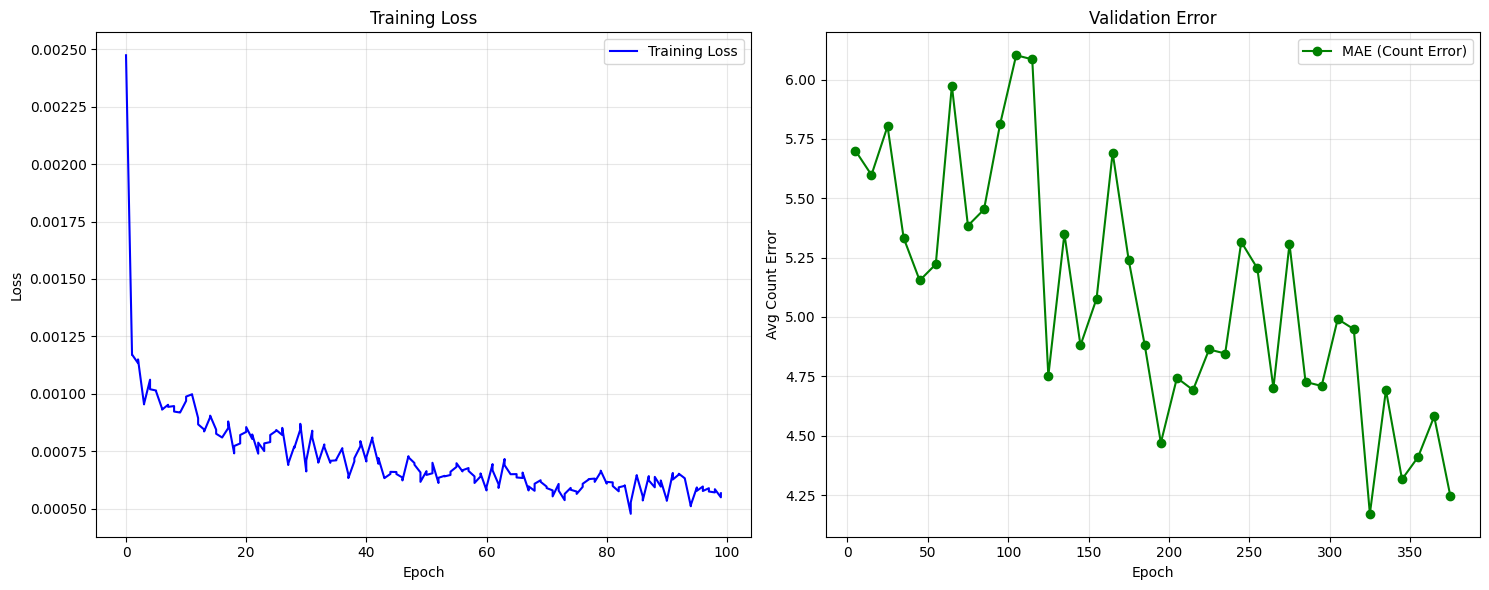

In [40]:
import matplotlib.pyplot as plt
import os
import re

# --- CONFIGURATION ---
LOG_PATH = r"C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project\CrowdCounting-P2PNet\output_finetune\run_log.txt"
# Save the image in the main project folder for easy access
SAVE_PATH = r"C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project\training_results.png"

def plot_graphs():
    if not os.path.exists(LOG_PATH):
        print(f"❌ Error: Log file not found at:\n{LOG_PATH}")
        return

    print(f"✅ Found log file! Reading data...")

    epochs_loss = []
    losses = []
    eval_epochs = []
    maes = []
    mses = []

    with open(LOG_PATH, 'r') as f:
        content = f.read()
    
    # 1. Parse Training Loss
    loss_pattern = re.compile(r'loss/loss@(\d+):\s*([\d\.]+)')
    for match in loss_pattern.finditer(content):
        epochs_loss.append(int(match.group(1)))
        losses.append(float(match.group(2)))

    # 2. Parse Validation MAE
    parts = content.split('mae:')
    for i, part in enumerate(parts[1:]): 
        current_eval_epoch = (i + 1) * 5 
        try:
            vals = part.split(',')
            mae = float(vals[0].strip())
            mse = float(vals[1].split(':')[1].strip())
            eval_epochs.append(current_eval_epoch)
            maes.append(mae)
            mses.append(mse)
        except: pass

    # --- PLOTTING ---
    plt.figure(figsize=(15, 6))

    # Graph 1: Training Loss
    plt.subplot(1, 2, 1)
    if epochs_loss:
        plt.plot(epochs_loss, losses, '-', color='blue', label='Training Loss')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
    else:
        plt.text(0.5, 0.5, "No Loss Data Found", ha='center')

    # Graph 2: MAE (Count Error)
    plt.subplot(1, 2, 2)
    if len(maes) > 0:
        plt.plot(eval_epochs, maes, '-o', color='green', label='MAE (Count Error)')
        plt.title('Validation Error')
        plt.xlabel('Epoch')
        plt.ylabel('Avg Count Error')
        plt.grid(True, alpha=0.3)
        plt.legend()
        print(f"🏆 Best MAE so far: {min(maes)}")
    else:
        plt.text(0.5, 0.5, "No Eval Data Yet", ha='center')

    plt.tight_layout()
    
    # --- SAVE BEFORE SHOW ---
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
    print(f"💾 Graph saved successfully to: {SAVE_PATH}")
    
    plt.show()

plot_graphs()

## Testing

=== RANDOM TEST CONFIG ===
📂 Repo: C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project\CrowdCounting-P2PNet
📂 Data: C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project\railway_dataset2\test_data\images
Loading weights: best_mae.pth


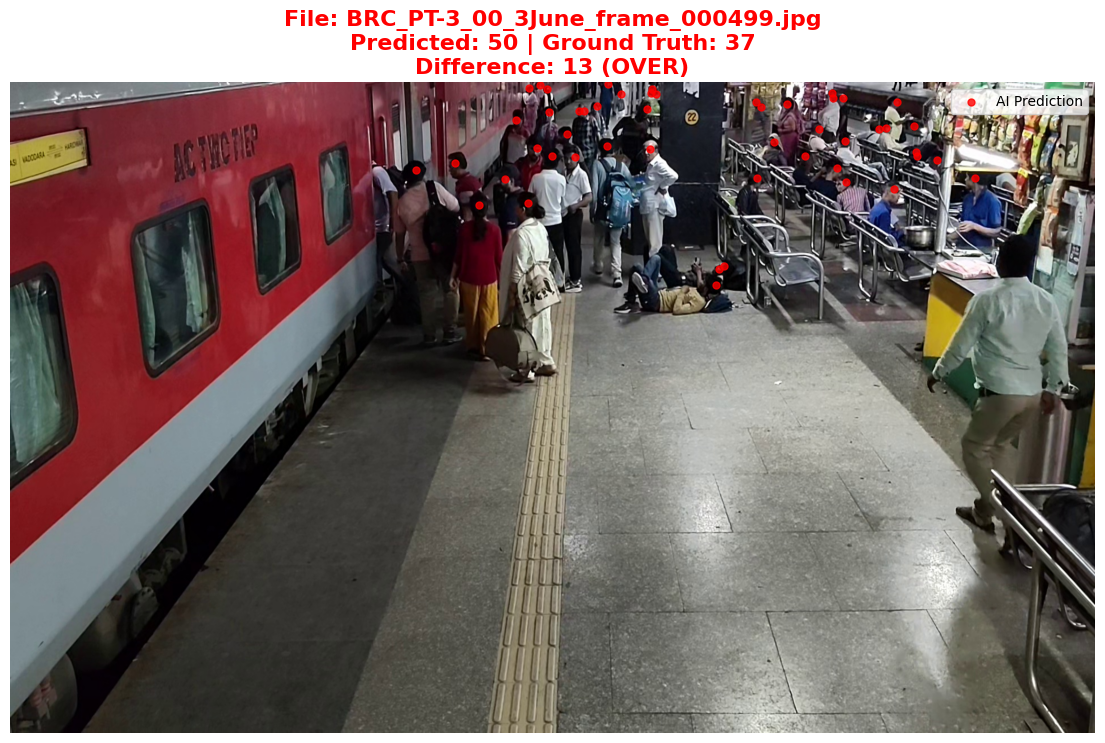

In [28]:
# ==============================================================================
# RANDOM INFERENCE CHECKER (Fixed Paths for Jupyter)
# ==============================================================================
import torch
import torch.nn.functional as F
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from models import build_model
import cv2
import math
import scipy.io as io
import sys

# --- 1. FIXED ABSOLUTE PATHS ---
# We hardcode the project root so Jupyter never gets confused
PROJECT_DIR = r"C:\Users\AIDSHPC01\Desktop\Crowd_Analysis_Project"

REPO_DIR = os.path.join(PROJECT_DIR, 'CrowdCounting-P2PNet')
DATASET_ROOT = os.path.join(PROJECT_DIR, 'railway_dataset2')
WEIGHTS_PATH = os.path.join(REPO_DIR, 'output_weights', 'best_mae.pth')

TEST_IMG_DIR = os.path.join(DATASET_ROOT, 'test_data', 'images')
TEST_GT_DIR = os.path.join(DATASET_ROOT, 'test_data', 'ground_truth')

# Settings
THRESHOLD = 0.14

# --- 2. SETUP ENVIRONMENT ---
if not os.path.exists(REPO_DIR):
    raise FileNotFoundError(f"Repo not found at: {REPO_DIR}")

# Add repo to python path so we can import modules
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

# Move to repo to load modules, then import
os.chdir(REPO_DIR)
from util.misc import NestedTensor
from models import build_model

print(f"=== RANDOM TEST CONFIG ===")
print(f"📂 Repo: {REPO_DIR}")
print(f"📂 Data: {TEST_IMG_DIR}")

# 3. HELPER: Get Ground Truth Count
def get_gt_count(img_filename):
    base = os.path.splitext(img_filename)[0]
    mat_path = os.path.join(TEST_GT_DIR, base + '.mat')
    txt_path = os.path.join(TEST_GT_DIR, base + '.txt')
    
    points = []
    if os.path.exists(txt_path):
        try:
            with open(txt_path) as f: points = f.readlines()
        except: pass
    elif os.path.exists(mat_path):
        try:
            mat = io.loadmat(mat_path)
            for k in ['image_info', 'annPoints', 'locations', 'points']:
                if k in mat: 
                    points = mat['image_info'][0][0][0][0][0] if k == 'image_info' else mat[k]
                    break
            if len(points) == 0:
                for k in mat:
                    if isinstance(mat[k], np.ndarray) and len(mat[k].shape) >= 2: points = mat[k]; break
        except: pass
    return len(points)

# 4. LOAD MODEL
def load_model():
    class Args:
        backbone='vgg16_bn'; row=2; line=2; gpu_id=0
        lr_backbone=0; masks=False; dilation=False

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model = build_model(Args()).to(device).eval()
    
    if not os.path.exists(WEIGHTS_PATH):
        print(f"❌ Error: Weights not found at {WEIGHTS_PATH}")
        return None, None
        
    print(f"Loading weights: {os.path.basename(WEIGHTS_PATH)}")
    ckpt = torch.load(WEIGHTS_PATH, map_location=device)
    state_dict = ckpt['model'] if 'model' in ckpt else ckpt
    
    # Remove 'module.' prefix if trained with Multi-GPU
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
        
    model.load_state_dict(new_state_dict)
    return model, device

# 5. PREDICT & VISUALIZE
def run_random_test():
    model, device = load_model()
    if model is None: return
    
    if not os.path.exists(TEST_IMG_DIR):
        print(f"❌ Error: Test image directory not found: {TEST_IMG_DIR}")
        return

    # Pick Random Image
    files = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if not files:
        print("No images found in test directory.")
        return
        
    filename = random.choice(files)
    img_path = os.path.join(TEST_IMG_DIR, filename)
    
    # Get GT
    gt_count = get_gt_count(filename)
    
    # Load Image
    img_raw = Image.open(img_path).convert('RGB')
    w, h = img_raw.size

    # Resize to nearest 128 (P2PNet requirement)
    new_w = int(math.ceil(w / 128.0)) * 128
    new_h = int(math.ceil(h / 128.0)) * 128
    img_resized = img_raw.resize((new_w, new_h), Image.BILINEAR)
    
    # Transform
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    tensor_img = transform(img_resized).unsqueeze(0).to(device)
    samples = NestedTensor(tensor_img, mask=None)

    # Inference
    with torch.no_grad():
        outputs = model(samples)

    # Process Output
    logits = outputs['pred_logits'][0]
    points = outputs['pred_points'][0]
    scores = F.softmax(logits, dim=-1)[:, 1]
    
    valid_indices = torch.where(scores > THRESHOLD)[0]
    pred_cnt = len(valid_indices)
    pred_points = points[valid_indices]

    # Calculate Error
    diff = pred_cnt - gt_count
    status = "PERFECT" if diff == 0 else ("OVER" if diff > 0 else "UNDER")
    color = 'green' if abs(diff) <= 3 else 'red'

    # --- PLOTTING ---
    plt.figure(figsize=(14, 10))
    plt.imshow(img_resized)
    
    title_text = (f"File: {filename}\n"
                  f"Predicted: {pred_cnt} | Ground Truth: {gt_count}\n"
                  f"Difference: {diff} ({status})")
    
    plt.title(title_text, fontsize=16, color=color, fontweight='bold')
    plt.axis('off')

    # Draw Prediction Dots (Red)
    if pred_cnt > 0:
        plt.scatter(pred_points[:, 0].cpu(), pred_points[:, 1].cpu(), c='red', s=25, label='AI Prediction', alpha=0.8)
    
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_random_test()